# Interactive verifier-time plot

Select a model and batch size, then plot:
- **X axis**: `tree_size`
- **Y axis**: `verifiertime_ms`
- **Lines**: one line per `kv_len`

Update `CSV_PATH` below to point to your data file.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Set this to your CSV file
CSV_PATH = 'verification_times.csv'

df = pd.read_csv(CSV_PATH)
df.head()

,tree_size,kv_len,bsz,verifiertime_ms,verifiertime_std_ms,attn_implementation,model_name
0,16,512,1,78.650901,0.127018,flex_attention,qwen/qwen3-4b
1,16,1024,1,115.957084,0.249647,flex_attention,qwen/qwen3-4b
2,16,2048,1,189.764524,0.306510,flex_attention,qwen/qwen3-4b
3,24,512,1,79.015132,0.133015,flex_attention,qwen/qwen3-4b
4,24,1024,1,116.782420,0.228660,flex_attention,qwen/qwen3-4b


In [6]:
required_cols = {
    'tree_size', 'kv_len', 'bsz', 'verifiertime_ms', 'model_name'
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

df['tree_size'] = pd.to_numeric(df['tree_size'])
df['kv_len'] = pd.to_numeric(df['kv_len'])
df['bsz'] = pd.to_numeric(df['bsz'])
df['verifiertime_ms'] = pd.to_numeric(df['verifiertime_ms'])

sorted(df['model_name'].unique()), sorted(df['bsz'].unique())

(['qwen/qwen3-14b', 'qwen/qwen3-4b', 'qwen/qwen3-8b'],
 [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)])

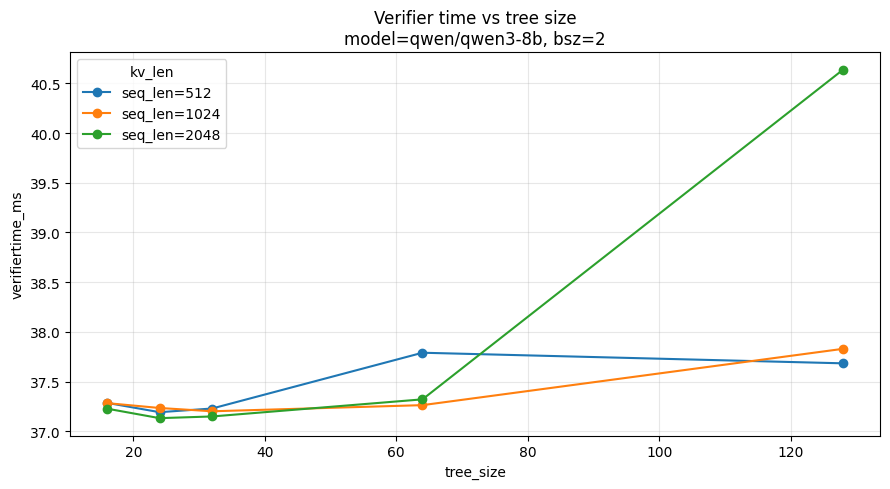

In [20]:
def plot_for(model_name, bsz):
    subset = df[(df['model_name'] == model_name) & (df['bsz'] == bsz)].copy()

    if subset.empty:
        print(f'No rows found for model={model_name!r}, bsz={bsz}')
        return

    plt.figure(figsize=(9, 5))
    for kv_len in sorted(subset['kv_len'].unique()):
        line = subset[subset['kv_len'] == kv_len].sort_values('tree_size')
        plt.plot(
            line['tree_size'],
            line['verifiertime_ms'],
            marker='o',
            label=f'seq_len={kv_len}'
        )

    plt.xlabel('tree_size')
    plt.ylabel('verifiertime_ms')
    plt.title(f'Verifier time vs tree size\nmodel={model_name}, bsz={bsz}')
    plt.legend(title='kv_len')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_for('qwen/qwen3-8b', 2)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Set this to your CSV file
CSV_PATH = 'drafting_times.csv'

df_draft = pd.read_csv(CSV_PATH)
df_draft.head()

,n_layers,tree_size,kv_len,draft_time_ms,draft_time_std_ms,attn_implementation,hidden_size
0,3,16,2048,4.090552,0.015030,flex_attention,2560
1,3,24,2048,4.085703,0.010578,flex_attention,2560
2,3,32,2048,4.107884,0.013135,flex_attention,2560
3,3,64,2048,4.213126,0.016072,flex_attention,2560
4,3,128,2048,3.055400,0.009013,flex_attention,2560


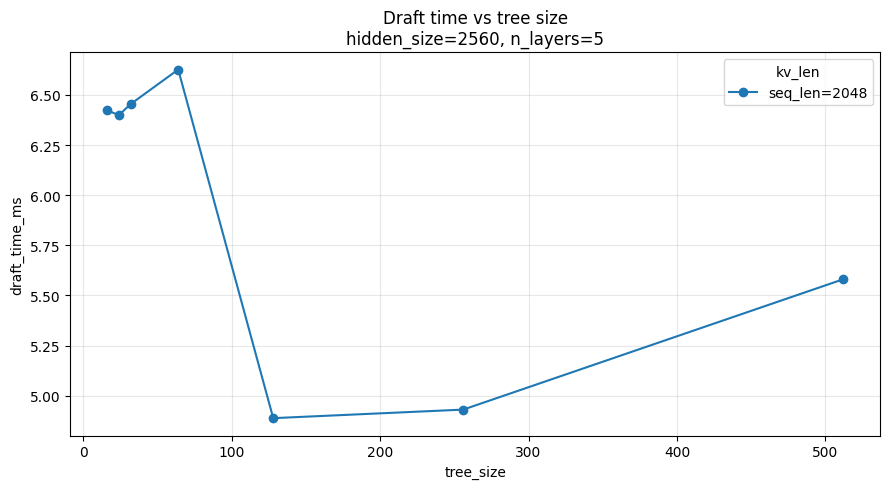

In [31]:
def plot_for_draft(hidden_size, n_layers):
    subset = df_draft[(df_draft['hidden_size'] == hidden_size) & (df_draft['n_layers'] == n_layers)].copy()

    plt.figure(figsize=(9, 5))
    for kv_len in sorted(subset['kv_len'].unique()):
        line = subset[subset['kv_len'] == kv_len].sort_values('tree_size')
        plt.plot(
            line['tree_size'],
            line['draft_time_ms'],
            marker='o',
            label=f'seq_len={kv_len}'
        )

    plt.xlabel('tree_size')
    plt.ylabel('draft_time_ms')
    plt.title(f'Draft time vs tree size\nhidden_size={hidden_size}, n_layers={n_layers}')
    plt.legend(title='kv_len')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_for_draft(2560, 5)